# Cloud Cover Analysis for Mission Planning

Cloud cover is a primary constraint for airborne remote sensing campaigns.
HyPlan's `clouds` module retrieves historical cloud fraction data and
simulates realistic mission visit schedules.

Two cloud data sources are available:

| Source | Resolution | Auth | Speed | Best for |
|--------|-----------|------|-------|----------|
| **Open-Meteo** (ERA5) | 0.25\u00b0 (~25 km) | None | ~3 seconds | Quick estimates, no setup |
| **Google Earth Engine** (MODIS) | 1 km | Google OAuth | Minutes | High-res per-pixel analysis |

We cover:

1. Study area definition
2. Retrieving cloud fraction via Open-Meteo (no auth)
3. Simulating mission visits with cloud, rest, and weekend constraints
4. Visualizing cloud fraction heatmaps with visit markers
5. Campaign planning insights
6. Google Earth Engine alternative (optional)

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import geopandas as gpd

from hyplan.clouds import (
    OpenMeteoCloudFraction,
    fetch_cloud_fraction,
    simulate_visits,
    plot_yearly_cloud_fraction_heatmaps_with_visits,
)

## 1. Study Area Definition

Cloud data is retrieved for polygons defined in a GeoJSON file. Each
polygon represents a study area (flight box) that needs to be imaged.
The GeoJSON must have a `Name` column identifying each polygon.

Study areas: 5 polygons
         Name
santa_barbara
        socal
     yosemite
        tahoe
     bay_area


Text(0.5, 1.0, 'Study Area Polygons')

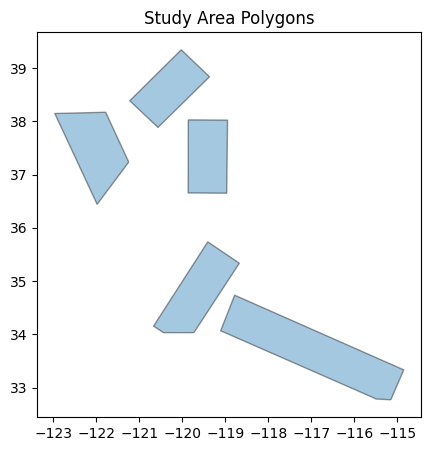

In [2]:
polygon_file = "exampledata/wdts.geojson"

gdf = gpd.read_file(polygon_file)
print(f"Study areas: {len(gdf)} polygons")
print(gdf[["Name"]].to_string(index=False))

ax = gdf.plot(figsize=(8, 5), alpha=0.4, edgecolor="black")
ax.set_title("Study Area Polygons")

## 2. Retrieve Cloud Fraction (Open-Meteo)

`OpenMeteoCloudFraction` fetches daily mean cloud cover from the
[Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api),
which serves ERA5 reanalysis data at 0.25\u00b0 resolution.

**No authentication required.** One HTTP request per polygon covers
the entire date range, so even 20-year queries complete in seconds.

In [3]:
import time

t0 = time.time()
cloud_data_df = fetch_cloud_fraction(
    polygon_file=polygon_file,
    year_start=2003,
    year_stop=2022,
    day_start=1,
    day_stop=75,
    source="openmeteo",
)
elapsed = time.time() - t0

print(f"Retrieved {len(cloud_data_df)} rows in {elapsed:.1f}s")
print(f"Columns: {list(cloud_data_df.columns)}")
print(f"Polygons: {sorted(cloud_data_df['polygon_id'].unique())}")
print(f"Years: {cloud_data_df['year'].min()}–{cloud_data_df['year'].max()}")
print(f"Cloud fraction range: {cloud_data_df['cloud_fraction'].min():.2f} – {cloud_data_df['cloud_fraction'].max():.2f}")
cloud_data_df.head(10)

Retrieved 7500 rows in 4.1s
Columns: ['polygon_id', 'year', 'day_of_year', 'cloud_fraction']
Polygons: ['bay_area', 'santa_barbara', 'socal', 'tahoe', 'yosemite']
Years: 2003–2022
Cloud fraction range: 0.00 – 1.00


,polygon_id,year,day_of_year,cloud_fraction
0,bay_area,2003,1,0.49
1,bay_area,2003,2,0.60
2,bay_area,2003,3,0.66
3,bay_area,2003,4,0.75
4,bay_area,2003,5,0.54
5,bay_area,2003,6,0.16
6,bay_area,2003,7,0.01
7,bay_area,2003,8,0.07
8,bay_area,2003,9,0.77
9,bay_area,2003,10,0.97


## 3. Simulate Mission Visits

`simulate_visits` takes the cloud fraction data and simulates a
realistic mission schedule. On each day, it checks whether each
study area is below the cloud fraction threshold. If so, the area
is "visited" (imaged). The simulation respects:

- **Cloud fraction threshold** \u2014 maximum cloudiness for a flyable day
- **Rest day schedule** \u2014 mandatory rest after N consecutive flight days
- **Weekend exclusion** \u2014 optionally skip weekends

This works identically regardless of whether the cloud data came
from Open-Meteo or Google Earth Engine.

In [4]:
# Simulate visits for February-March window
day_start = 30
day_stop = 74

visit_days_df, visit_tracker, rest_days = simulate_visits(
    cloud_data_df,
    day_start=day_start,
    day_stop=day_stop,
    year_start=2003,
    year_stop=2022,
    cloud_fraction_threshold=0.25,  # Max 25% cloud cover
    rest_day_threshold=5,           # Rest after 5 consecutive flight days
    exclude_weekends=True,          # No flights on weekends
)

print(f"Visit results: {len(visit_days_df)} years simulated")
print(f"Average campaign days: {visit_days_df['days'].mean():.0f}")
visit_days_df

Visit results: 20 years simulated
Average campaign days: 18


,year,days
0,2003,8
1,2004,13
2,2005,6
3,2006,16
4,2007,21
5,2008,14
6,2009,12
7,2010,45
8,2011,9
9,2012,18


## 4. Visualize Cloud Fraction Heatmaps

The heatmap shows daily cloud conditions for each study area across the
campaign window. Colors indicate:
- **White** \u2014 clear day (below threshold)
- **Black** \u2014 cloudy day (above threshold)
- **Grey** \u2014 already visited (no longer needed)
- **Purple** \u2014 weekend (excluded)
- **Orange** \u2014 mandatory rest day
- **Red star** \u2014 visit day

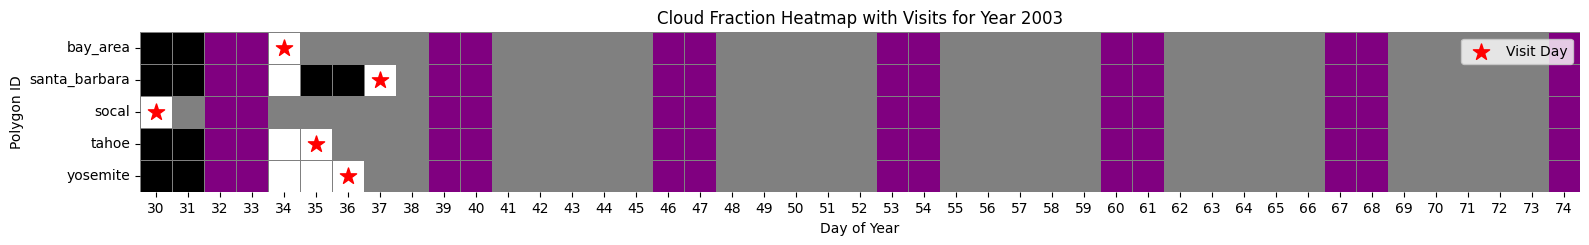

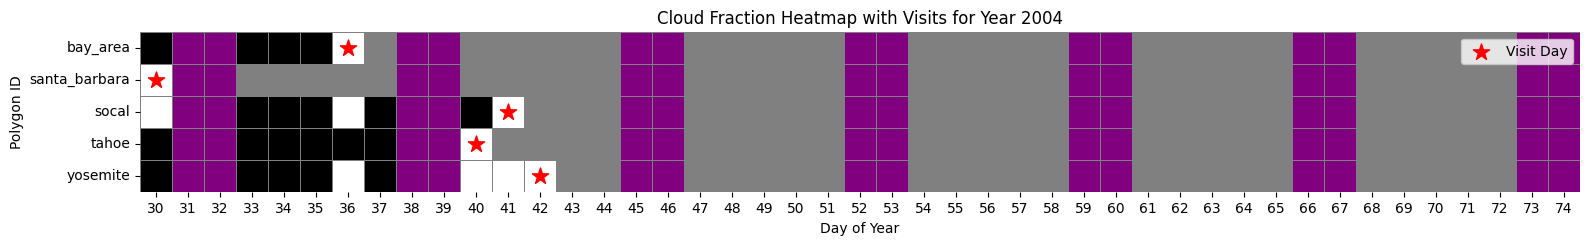

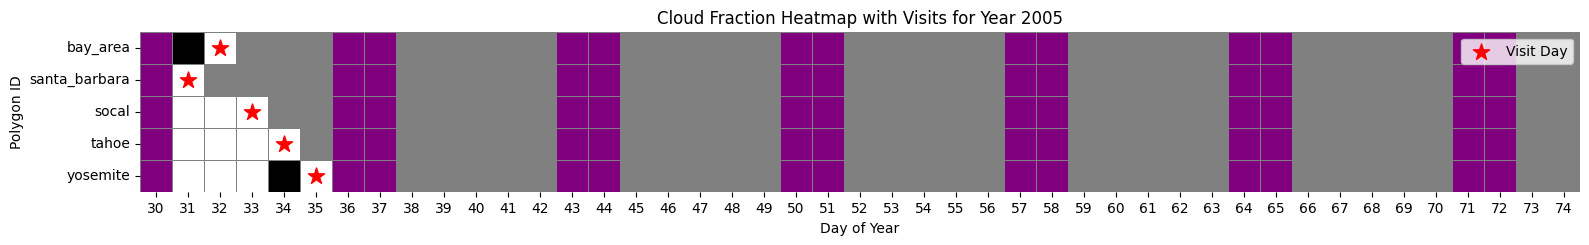

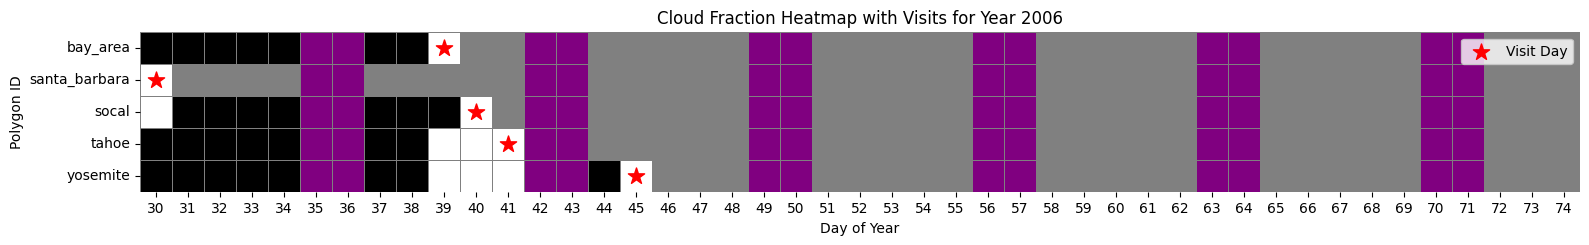

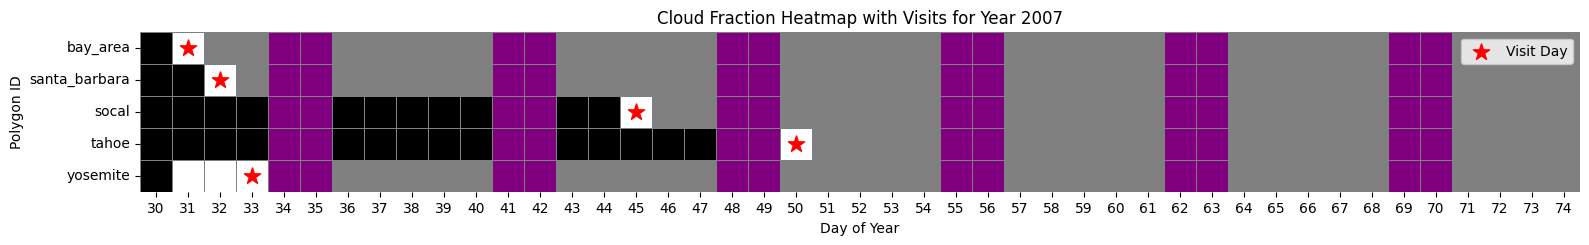

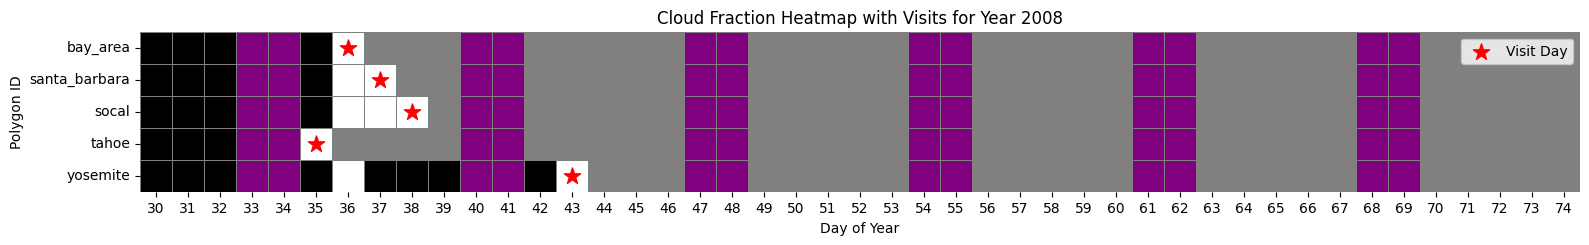

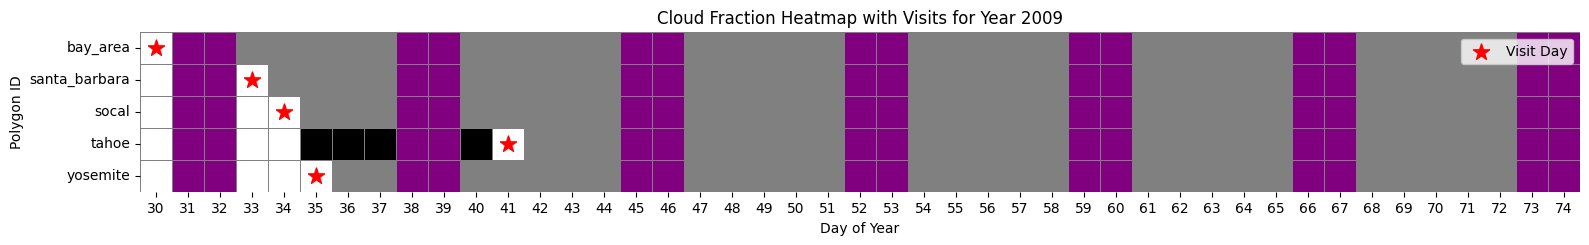

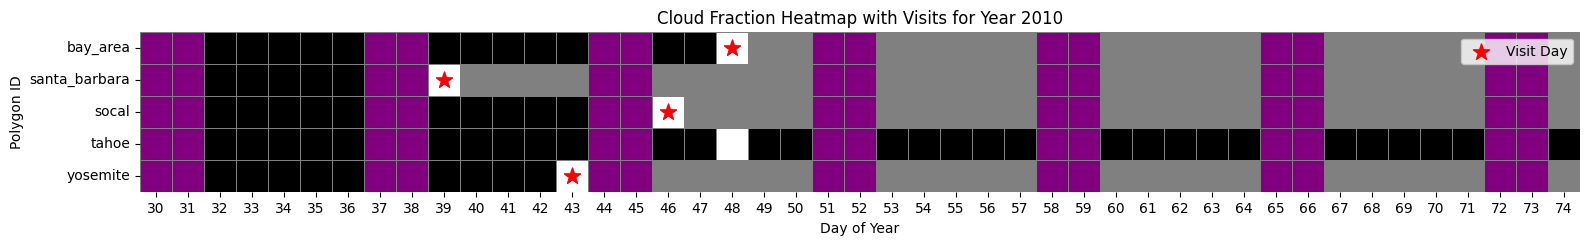

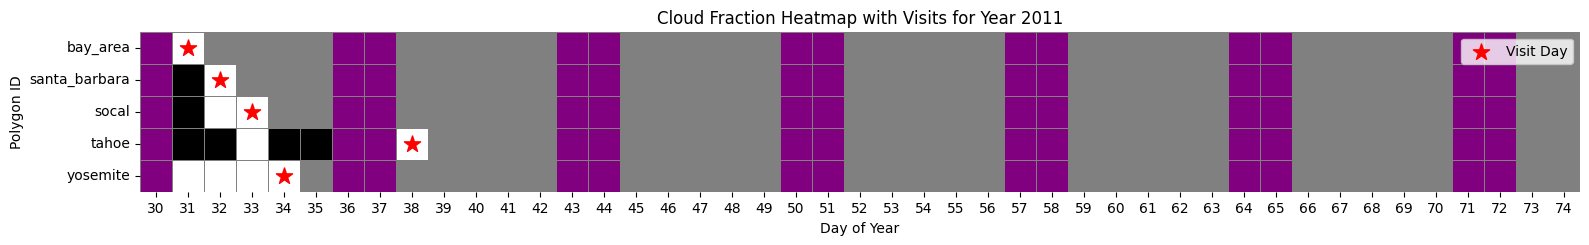

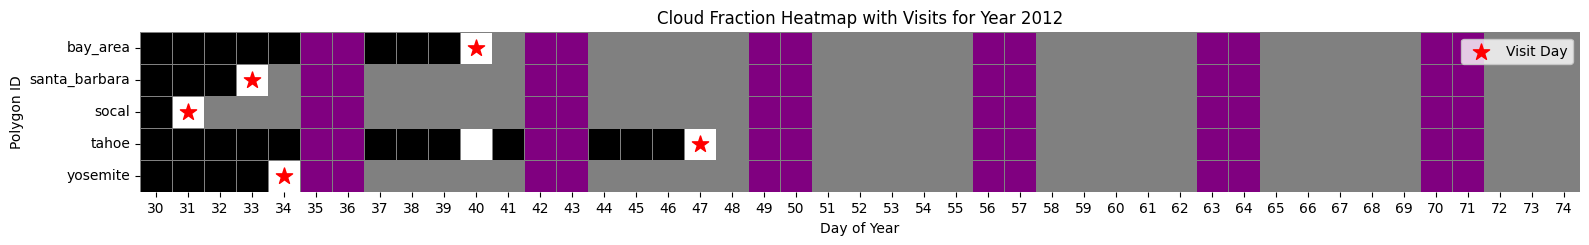

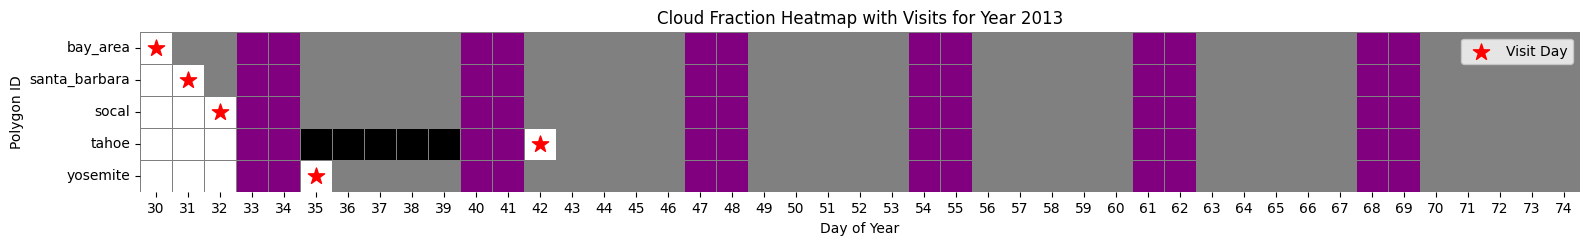

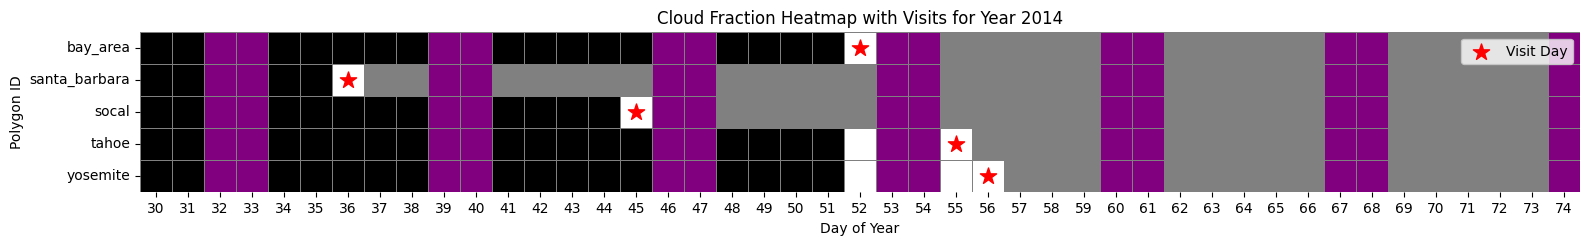

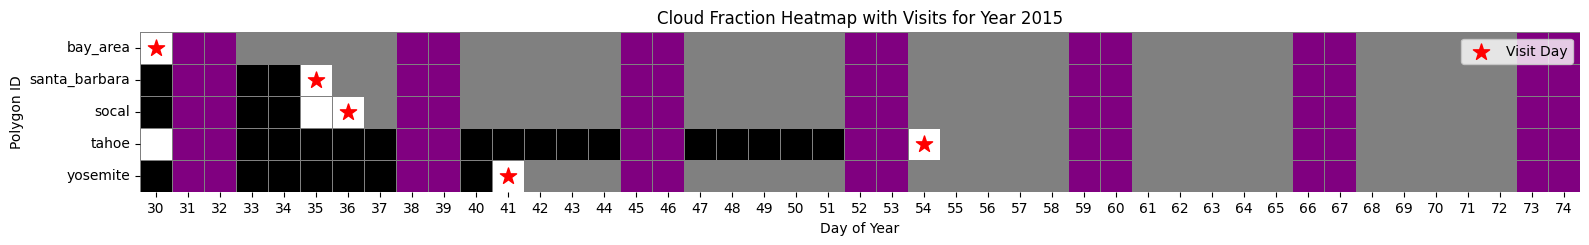

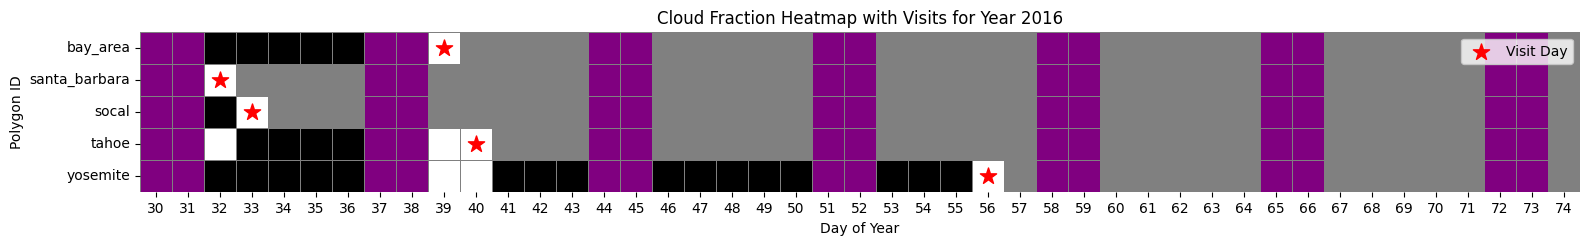

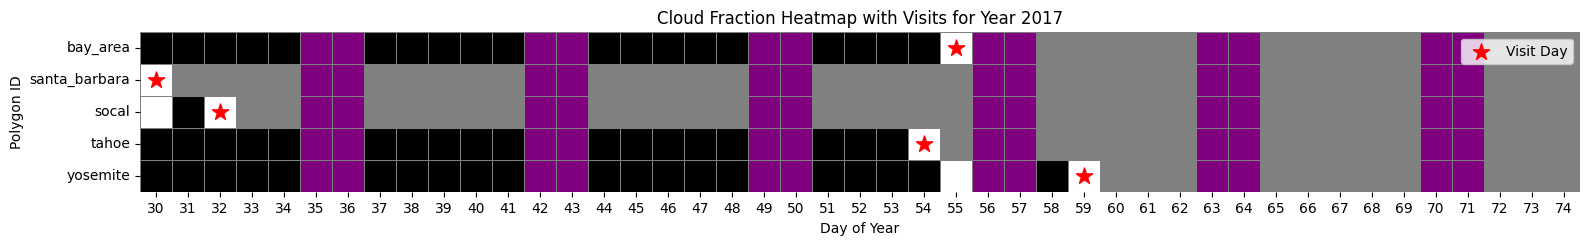

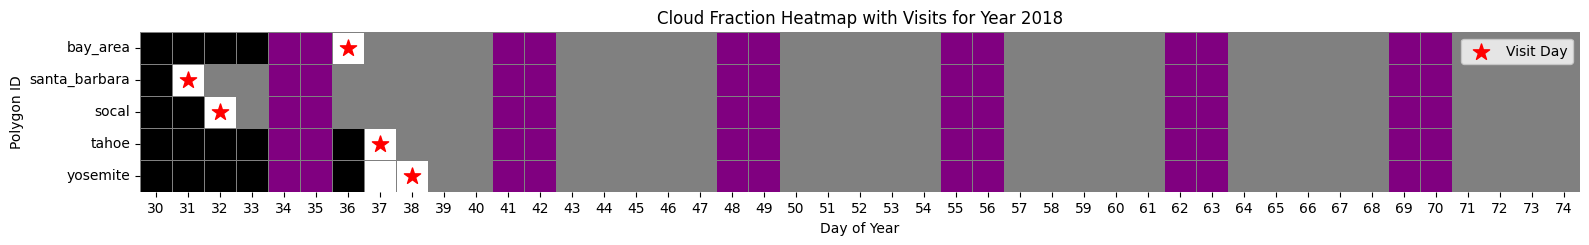

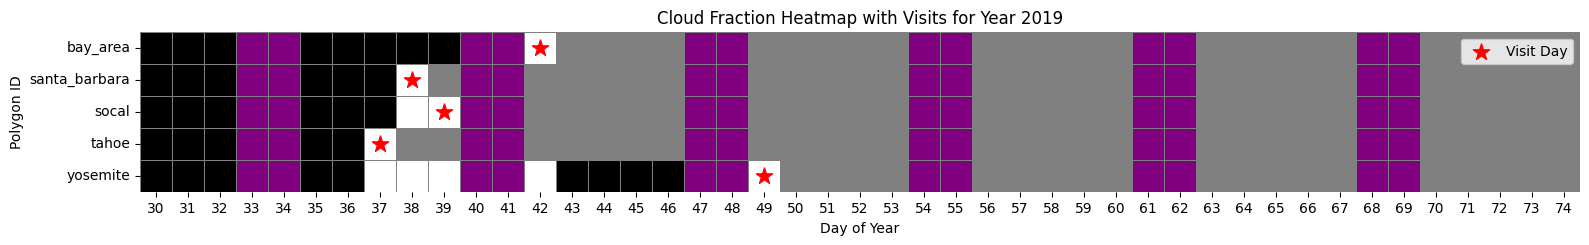

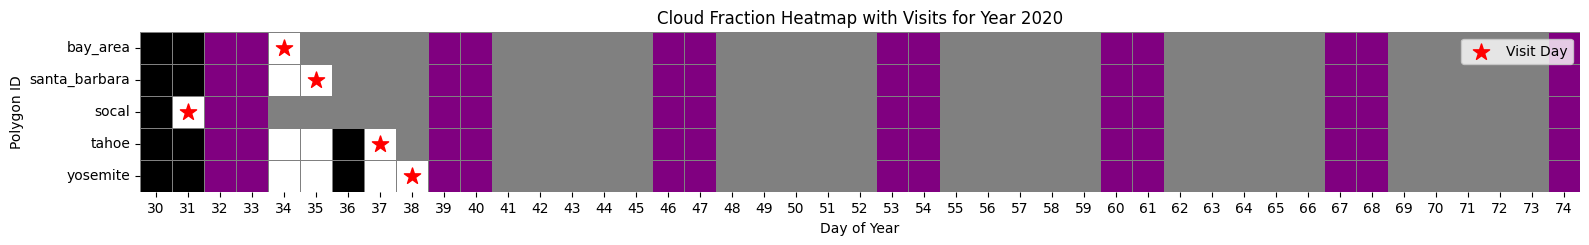

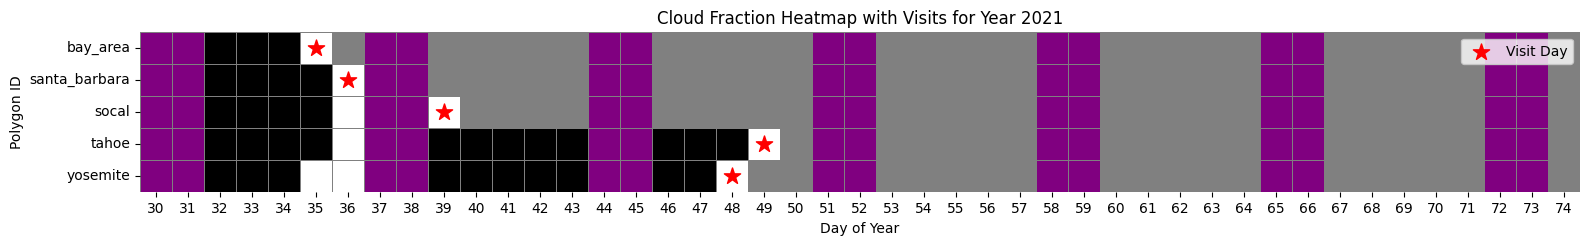

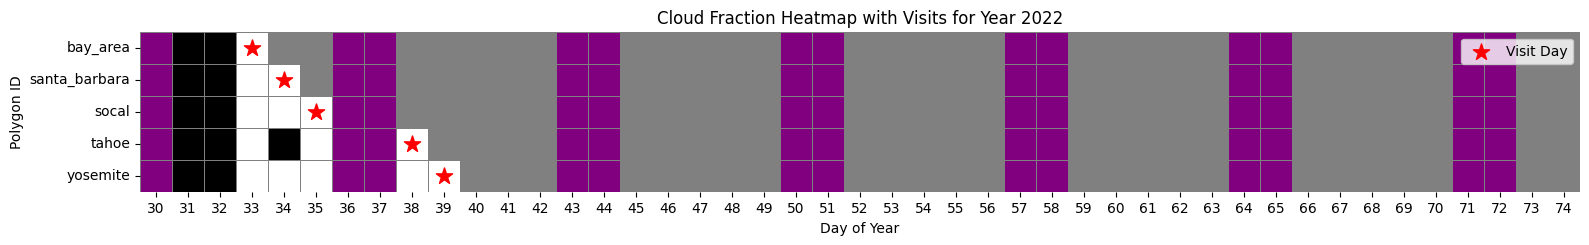

In [5]:
plot_yearly_cloud_fraction_heatmaps_with_visits(
    cloud_data_df,
    visit_tracker,
    rest_days,
    cloud_fraction_threshold=0.25,
    exclude_weekends=True,
    day_start=day_start,
    day_stop=day_stop,
)

## 5. Campaign Planning Insights

Use the simulation results to answer key planning questions:

- How many flyable days per study area?
- What cloud threshold gives adequate coverage?
- How long should the campaign window be?

In [6]:
polygons = sorted(cloud_data_df["polygon_id"].unique())
years = list(range(2003, 2023))

print("Flyable days per study area (25% cloud threshold):\n")
print(f"{'Area':<12s}", end="")
for y in years[:5]:
    print(f"  {y}", end="")
print("  ...  Mean")
print("-" * 52)

for poly in polygons:
    counts = []
    for y in years:
        n = len(visit_tracker.get(y, {}).get(poly, []))
        counts.append(n)
    print(f"{poly:<12s}", end="")
    for c in counts[:5]:
        print(f"  {c:4d}", end="")
    print(f"  ...  {np.mean(counts):4.1f}")

Flyable days per study area (25% cloud threshold):

Area          2003  2004  2005  2006  2007  ...  Mean
----------------------------------------------------
bay_area         1     1     1     1     1  ...   1.0
santa_barbara     1     1     1     1     1  ...   1.0
socal            1     1     1     1     1  ...   1.0
tahoe            1     1     1     1     1  ...   0.9
yosemite         1     1     1     1     1  ...   1.0


In [7]:
# --- Question 2: What cloud threshold gives adequate coverage? ---
# Compare how many areas get visited at least once per year across thresholds

thresholds = [0.10, 0.15, 0.20, 0.25, 0.35, 0.50]

rows = []
for thresh in thresholds:
    _, vt, _ = simulate_visits(
        cloud_data_df,
        day_start=day_start,
        day_stop=day_stop,
        year_start=2003,
        year_stop=2006,
        cloud_fraction_threshold=thresh,
        rest_day_threshold=2,
        exclude_weekends=True,
        debug=False,
    )
    for y in years:
        visits_per_area = {p: len(vt.get(y, {}).get(p, [])) for p in polygons}
        rows.append({
            "threshold": thresh,
            "year": y,
            "areas_visited": sum(1 for v in visits_per_area.values() if v > 0),
            "total_visits": sum(visits_per_area.values()),
            "min_visits": min(visits_per_area.values()),
        })

threshold_df = pd.DataFrame(rows)
summary = threshold_df.groupby("threshold").agg(
    avg_areas_visited=("areas_visited", "mean"),
    avg_total_visits=("total_visits", "mean"),
    avg_min_visits=("min_visits", "mean"),
).reset_index()

print("Impact of cloud fraction threshold (averaged over 2003-2006):\n")
print(f"{'Threshold':>10s}  {'Areas Visited':>14s}  {'Total Visits':>13s}  {'Min per Area':>13s}")
print("-" * 56)
for _, row in summary.iterrows():
    print(f"{row['threshold']:>10.0%}  {row['avg_areas_visited']:>14.1f}  {row['avg_total_visits']:>13.1f}  {row['avg_min_visits']:>13.1f}")

Impact of cloud fraction threshold (averaged over 2003-2006):

 Threshold   Areas Visited   Total Visits   Min per Area
--------------------------------------------------------
       10%             0.9            0.9            0.1
       15%             1.0            1.0            0.2
       20%             1.0            1.0            0.2
       25%             1.0            1.0            0.2
       35%             1.0            1.0            0.2
       50%             1.0            1.0            0.2


In [8]:
# --- Question 3: How long should the campaign window be? ---
# Simulate different window lengths and see how many areas get covered

window_lengths = [14, 21, 30, 45, 60]
# Center windows around DOY 52 (late Feb)
center_doy = 52

rows = []
for wlen in window_lengths:
    ds = center_doy - wlen // 2
    de = ds + wlen - 1
    _, vt, _ = simulate_visits(
        cloud_data_df,
        day_start=ds,
        day_stop=de,
        year_start=2003,
        year_stop=2006,
        cloud_fraction_threshold=0.25,
        rest_day_threshold=2,
        exclude_weekends=True,
        debug=False,
    )
    for y in years:
        visits_per_area = {p: len(vt.get(y, {}).get(p, [])) for p in polygons}
        all_flight_days = set()
        for p in polygons:
            all_flight_days.update(vt.get(y, {}).get(p, []))
        rows.append({
            "window_days": wlen,
            "year": y,
            "areas_covered": sum(1 for v in visits_per_area.values() if v > 0),
            "total_visits": sum(visits_per_area.values()),
            "flight_days": len(all_flight_days),
        })

window_df = pd.DataFrame(rows)
wsummary = window_df.groupby("window_days").agg(
    avg_areas=("areas_covered", "mean"),
    avg_visits=("total_visits", "mean"),
    avg_flight_days=("flight_days", "mean"),
).reset_index()

print("Campaign window length vs. coverage (25% threshold, centered on late Feb):\n")
print(f"{'Window (days)':>14s}  {'Areas Covered':>14s}  {'Total Visits':>13s}  {'Flight Days':>12s}")
print("-" * 58)
for _, row in wsummary.iterrows():
    print(f"{row['window_days']:>14.0f}  {row['avg_areas']:>14.1f}  {row['avg_visits']:>13.1f}  {row['avg_flight_days']:>12.1f}")

Campaign window length vs. coverage (25% threshold, centered on late Feb):



 Window (days)   Areas Covered   Total Visits   Flight Days
----------------------------------------------------------
            14             0.5            0.5           0.5
            21             0.6            0.6           0.6
            30             0.8            0.8           0.8
            45             1.0            1.0           1.0
            60             1.0            1.0           1.0


## 6. Google Earth Engine Alternative (Optional)

For higher-resolution cloud analysis (1 km MODIS vs 25 km ERA5), use the
GEE path. This requires a Google Earth Engine account and authentication.

```python
import ee
ee.Authenticate()  # First time only
ee.Initialize()

from hyplan.clouds import create_cloud_data_array_with_limit

# Same output format \u2014 works with simulate_visits and plotting
cloud_data_gee = create_cloud_data_array_with_limit(
    polygon_file=polygon_file,
    year_start=2003,
    year_stop=2022,
    day_start=1,
    day_stop=75,
)

# Or via the factory:
# cloud_data_gee = fetch_cloud_fraction(polygon_file, 2003, 2022, 1, 75, source="gee")
```

The GEE path uses MODIS Terra/Aqua MOD09GA/MYD09GA surface reflectance
with the `state_1km` quality assessment band to classify each pixel as
clear, cloudy, or mixed.